#### P3-05
# Feature Engineering
#### M03

## 1. Setup

In [7]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import add_features

pd.set_option("display.max_columns", None)

SPLIT_DIR = ROOT / "data" / "processed" / "split"
OUT_DIR = ROOT / "data" / "processed" / "feature_engineered"

## 2. Load Data

Train, validation, and test splits produced by notebook 05.

In [8]:
hotel_train = pd.read_csv(SPLIT_DIR / "hotel_bookings_train.csv")
hotel_val = pd.read_csv(SPLIT_DIR / "hotel_bookings_val.csv")
hotel_test = pd.read_csv(SPLIT_DIR / "hotel_bookings_test.csv")

print(hotel_train.shape)
print(hotel_val.shape)
print(hotel_test.shape)

(58990, 37)
(10544, 37)
(17406, 37)


In [9]:
hotel_train.head()

,Unnamed: 0.1,Unnamed: 0,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date_month_num,arrival_date,booking_date
0,0,0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,2015-07-01,2014-07-24
1,1,1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,2015-07-01,2013-06-24
2,2,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,2015-07-01,2015-06-24
3,3,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,2015-07-01,2015-06-18
4,4,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,7,2015-07-01,2015-06-17


## 3. Feature Engineering

`add_features` in `src/features.py` adds five columns. Each one is computed from the current row only:

- `total_nights`: weekend nights plus weekday nights
- `total_guests`: adults plus children plus babies
- `has_kids`: 1 when children or babies are present, otherwise 0
- `season`: winter, spring, summer, or autumn from the arrival month
- `arrival_day_of_week`: weekday name of `arrival_date`

None of these use `reservation_status`, `reservation_status_date`, `assigned_room_type`, or `required_car_parking_spaces`.

In [10]:
hotel_train = add_features(hotel_train)
hotel_val = add_features(hotel_val)
hotel_test = add_features(hotel_test)

## 4. Validation Checks

In [11]:
NEW_FEATURES = [
    "total_nights",
    "total_guests",
    "has_kids",
    "season",
    "arrival_day_of_week",
]

print(list(hotel_train.columns) == list(hotel_val.columns) == list(hotel_test.columns))
print((hotel_train["total_nights"] == hotel_train["stays_in_weekend_nights"] + hotel_train["stays_in_week_nights"]).all())
print(sorted(hotel_train["season"].unique()))
print(sorted(hotel_train["has_kids"].unique()))
hotel_train[NEW_FEATURES].head()

True
True
['Autumn', 'Spring', 'Summer', 'Winter']
[np.int64(0), np.int64(1)]


,total_nights,total_guests,has_kids,season,arrival_day_of_week
0,0,2.0,0,Summer,Wednesday
1,0,2.0,0,Summer,Wednesday
2,1,1.0,0,Summer,Wednesday
3,1,1.0,0,Summer,Wednesday
4,2,2.0,0,Summer,Wednesday


## 5. Cancellation rate by new feature

Rates below use the training split only. Each bar is the percentage of bookings in that group with `is_canceled` = 1.

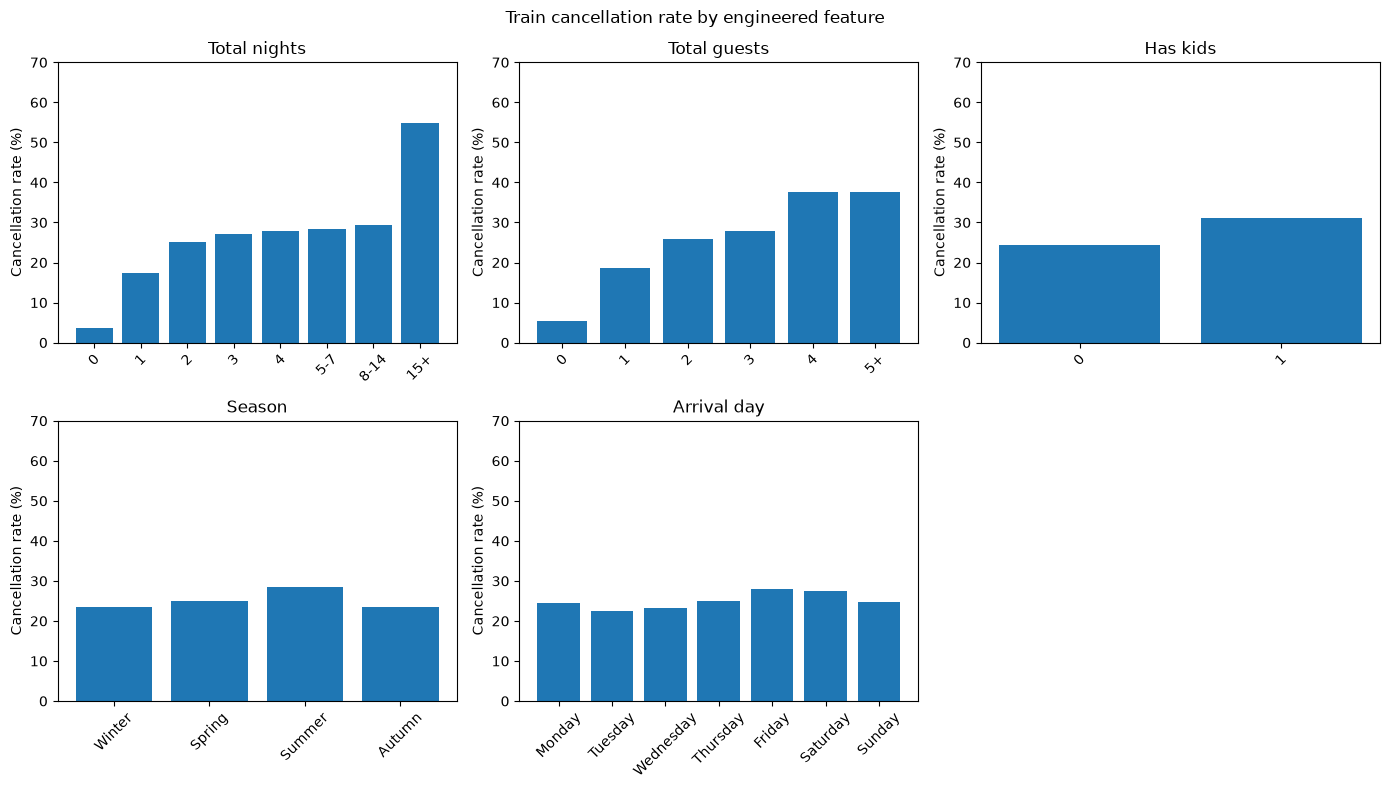

In [12]:
import matplotlib.pyplot as plt

train_plot = hotel_train.copy()
train_plot["nights_range"] = pd.cut(
    train_plot["total_nights"],
    bins=[-0.1, 0, 1, 2, 3, 4, 7, 14, 60],
    labels=["0", "1", "2", "3", "4", "5-7", "8-14", "15+"],
)
train_plot["guests_range"] = pd.cut(
    train_plot["total_guests"],
    bins=[-0.1, 0, 1, 2, 3, 4, 60],
    labels=["0", "1", "2", "3", "4", "5+"],
)

plots = [
    ("nights_range", "Total nights", None),
    ("guests_range", "Total guests", None),
    ("has_kids", "Has kids", [0, 1]),
    ("season", "Season", ["Winter", "Spring", "Summer", "Autumn"]),
    (
        "arrival_day_of_week",
        "Arrival day",
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, (col, title, order) in zip(axes, plots):
    rates = (
        train_plot.groupby(col, observed=True)["is_canceled"]
        .mean()
        .mul(100)
    )
    if order is not None:
        rates = rates.reindex(order)
    ax.bar(rates.index.astype(str), rates.values)
    ax.set_ylim(0, 70)
    ax.set_title(title)
    ax.set_ylabel("Cancellation rate (%)")
    ax.tick_params(axis="x", rotation=45)

axes[-1].axis("off")
fig.suptitle("Train cancellation rate by engineered feature")
fig.tight_layout()
plt.show()

On the training split, cancellation rises with stay length (about 4% for 0 nights, about 55% for 15 or more) and with party size (about 19% for 1 guest, about 38% for 4 guests). Bookings with children cancel more often than bookings without (about 31% versus 24%). Summer is a little higher than the other seasons, and Friday and Saturday arrivals are a little higher than mid-week arrivals.

## 6. Save Processed Datasets

In [13]:
splits = {
    "train": hotel_train,
    "val": hotel_val,
    "test": hotel_test,
}

for name, frame in splits.items():
    frame.to_csv(OUT_DIR / f"hotel_{name}_fe.csv", index=False)

## 7. Summary

- The same five features are added to train, validation, and test.
- Each feature is simple per-row math. No category grouping and no features learned from the training set.
- On the training split, longer stays and larger parties have higher cancellation rates. Children, summer, and weekend arrivals have smaller gaps.
- Saved to `data/processed/feature_engineered/`.